# Исследование арбитражной стратегии
_Трусковская Д.Р._

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates
import seaborn as sns
#%matplotlib inline

from tqdm.notebook import tqdm

In [2]:
#import datetime
import requests
import apimoex

In [3]:
#import os, re
import warnings
warnings.filterwarnings('ignore')

In [4]:
plt.rcParams['font.family'] = 'Times New Roman'

## Загрузка котировок

### Фьючерсы

In [5]:
#Список нужных фьючерсов
#MIX-12.25  -> MXZ5
#RTS-12.25  -> RIZ5
#Si-12.25   -> SiZ5
df_listing = pd.DataFrame({'SECID': ['MXZ5', 'RIZ5', 'SiZ5'],
                           'CONTRACT': ['MIX-12.25', 'RTS-12.25', 'Si-12.25']})

df_futures = pd.DataFrame()  #Общий df для всех трёх контрактов

#Период истории
history_from = '2025-03-01'
history_till = '2025-12-31'

#Загрузка котировок по каждому фьючерсу из df_listing
#for index, row in df_listing.iterrows():  #цикл по каждой строке в листинге
for index, row in tqdm(df_listing.iterrows(),total=len(df_listing),desc='Загрузка котировок фьючерсов'): #цикл по каждой строке в листинге
    security_id = row['SECID']
    contract_name = row['CONTRACT']

    try:
        #Берем 1H вместо 1D
        #Используем get_board_candles с interval=60
        with requests.Session() as session:
            data = apimoex.get_board_candles(session,security=security_id,
                interval=60,             # 60 = 1 час
                start=history_from,end=history_till,
                board='RFUD',market='forts',engine='futures')
                #columns можно не указывать, по умолчанию: begin, open, close, high, low, value, volume

        df = pd.DataFrame(data)

        #У свечек нет TRADEDATE, есть begin - момент начала свечи
        df.rename(columns={'begin': 'TRADEDATE'}, inplace=True)
        df.rename(columns={'close': 'CLOSE'}, inplace=True)
        df.set_index('TRADEDATE', inplace=True)

        df['SECID'] = security_id
        df['CONTRACT'] = contract_name

        df_futures = pd.concat([df_futures, df], ignore_index=False)

    except Exception as e:
        print(f"Ошибка при загрузке данных для {security_id}: {e}")

Загрузка котировок фьючерсов:   0%|          | 0/3 [00:00<?, ?it/s]

In [6]:
df_futures#.head()

,open,CLOSE,high,low,value,volume,SECID,CONTRACT
TRADEDATE,,,,,,,,
2025-03-03 09:00:00,368300,368300,368300,368300,0,1,MXZ5,MIX-12.25
2025-03-03 10:00:00,365375,361725,365375,361725,0,2,MXZ5,MIX-12.25
2025-03-03 11:00:00,359400,362700,362700,359400,0,7,MXZ5,MIX-12.25
2025-03-03 12:00:00,359400,351875,359400,351875,0,12,MXZ5,MIX-12.25
2025-03-03 13:00:00,358650,364975,364975,358650,0,8,MXZ5,MIX-12.25
...,...,...,...,...,...,...,...,...
2025-12-04 13:00:00,77111,76948,77185,76820,0,94301,SiZ5,Si-12.25
2025-12-04 14:00:00,76949,77037,77049,76900,0,38488,SiZ5,Si-12.25
2025-12-04 15:00:00,77036,77075,77275,76995,0,64138,SiZ5,Si-12.25


In [7]:
#Преобразуем df_futures в формат: дата, MXZ5, RIZ5, SiZ5 (по цене CLOSE)
#Делаем TRADEDATE обычным столбцом и строим сводную таблицу
df_close = (df_futures.reset_index()  # TRADEDATE делаем столбцом
    .pivot(index='TRADEDATE', columns='SECID', values='CLOSE')  #столбцы = SECID, значения = CLOSE
    .sort_index())

#df_close = df_close.reset_index() #если нужна именно дата как столбец, а не индекс

#Расставляем столбцы в нужном порядке
desired_cols = ['TRADEDATE', 'MXZ5', 'RIZ5', 'SiZ5']
df_close = df_close[[col for col in desired_cols if col in df_close.columns]]

In [8]:
df_close#.head()

SECID,MXZ5,RIZ5,SiZ5
TRADEDATE,,,
2025-03-03 08:00:00,NaN,NaN,101599.0
2025-03-03 09:00:00,368300.0,114230.0,101986.0
2025-03-03 10:00:00,361725.0,NaN,102599.0
2025-03-03 11:00:00,362700.0,112830.0,101660.0
2025-03-03 12:00:00,351875.0,112810.0,101700.0
...,...,...,...
2025-12-04 13:00:00,268100.0,109830.0,76948.0
2025-12-04 14:00:00,268225.0,109770.0,77037.0
2025-12-04 15:00:00,268525.0,109840.0,77075.0


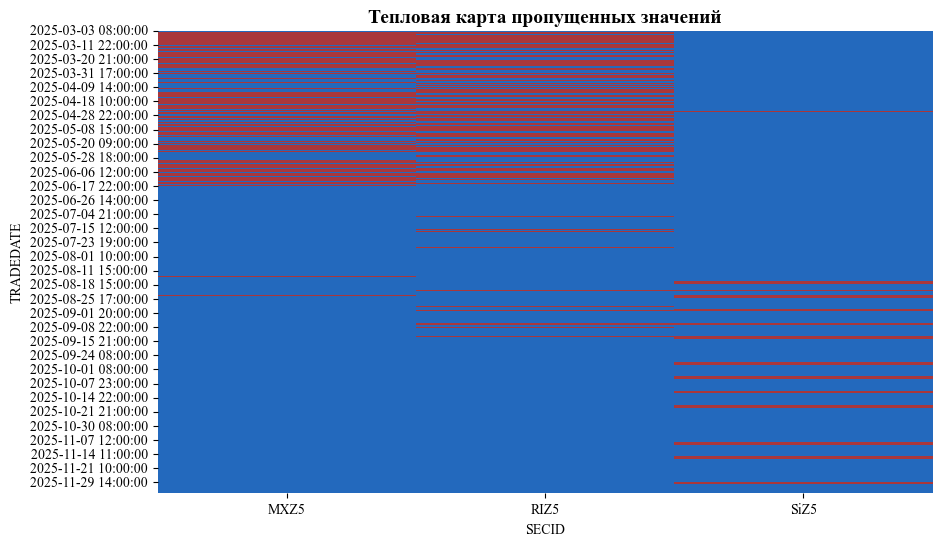

In [9]:
#Создание тепловой карты пропущенных значений
plt.figure(figsize=(10, 6))
sns.heatmap(df_close.isnull(), cmap='vlag', cbar=False)
plt.title('Тепловая карта пропущенных значений', fontdict={'fontweight': 'bold', 'fontsize': 14})
plt.show()

In [10]:
df_filled = df_close.copy()

#Группируем данные по SECID и заполняем пропуски в CLOSE отдельно для каждой группы
df_filled = df_filled.fillna(method='ffill')
#Удаляем строки, где значение CLOSE остается NaN (если не было значений для заполнения)
df_filled = df_filled.dropna()
df_filled

SECID,MXZ5,RIZ5,SiZ5
TRADEDATE,,,
2025-03-03 09:00:00,368300.0,114230.0,101986.0
2025-03-03 10:00:00,361725.0,114230.0,102599.0
2025-03-03 11:00:00,362700.0,112830.0,101660.0
2025-03-03 12:00:00,351875.0,112810.0,101700.0
2025-03-03 13:00:00,364975.0,111500.0,101950.0
...,...,...,...
2025-12-04 13:00:00,268100.0,109830.0,76948.0
2025-12-04 14:00:00,268225.0,109770.0,77037.0
2025-12-04 15:00:00,268525.0,109840.0,77075.0


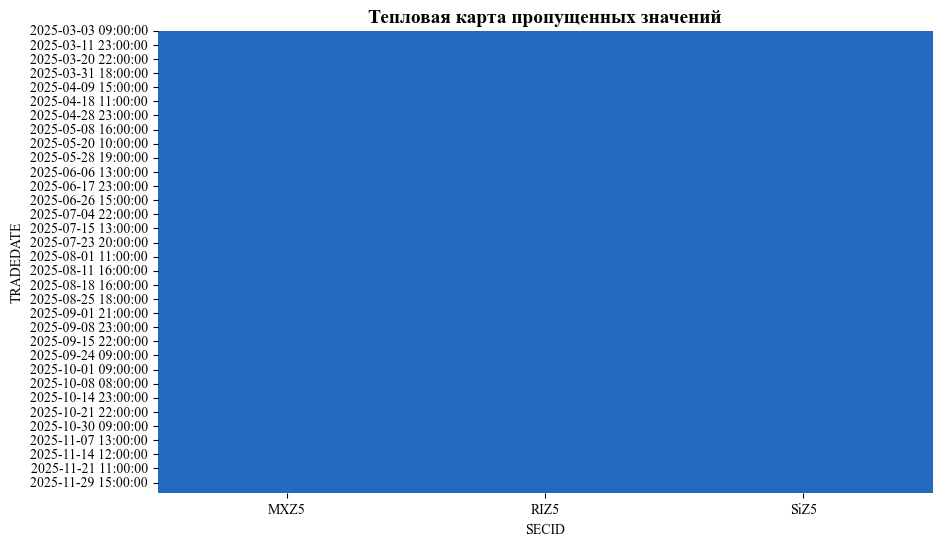

In [11]:
#Создание тепловой карты пропущенных значений
plt.figure(figsize=(10, 6))
sns.heatmap(df_filled.isnull(), cmap='vlag', cbar=False)
plt.title('Тепловая карта пропущенных значений', fontdict={'fontweight': 'bold', 'fontsize': 14})
plt.show()

In [12]:
#Лог-цены и лог-доходности
#log_prices = np.log(df_close)
log_prices = np.log(df_filled)
returns = log_prices.diff().dropna()

### Спот

In [13]:
#Список нужных спотов: IMOEX, RTSI, USDRUB (через USD000UTSTOM)
df_spot_listing = pd.DataFrame({'SECID': ['IMOEX', 'RTSI', 'USD000UTSTOM'],
                                'ALIAS': ['IMOEX', 'RTSI', 'USDRUB'],
                                'ENGINE': ['stock', 'stock', 'currency'],
                                'MARKET': ['index', 'index', 'selt'],
                                'BOARD':  ['SNDX', 'SNDX', 'CETS']})

df_spot = pd.DataFrame()

history_from_spot = '2024-01-01'
history_till_spot = '2024-12-31'

for index, row in tqdm(df_spot_listing.iterrows(),
                       total=len(df_spot_listing),
                       desc='Загрузка спот-данных'):
    security_id = row['SECID']
    alias = row['ALIAS']
    engine = row['ENGINE']
    market = row['MARKET']
    board = row['BOARD']

    try:
        with requests.Session() as session:
            data = apimoex.get_board_candles(session,security=security_id,
                                             interval=24,             #дневные свечи
                                             start=history_from_spot,end=history_till_spot,
                                             board=board,market=market,engine=engine)

        df = pd.DataFrame(data)
        df.rename(columns={'begin': 'TRADEDATE', 'close': alias}, inplace=True)
        df.set_index('TRADEDATE', inplace=True)

        # аккуратно склеиваем по дате
        if df_spot.empty:
            df_spot = df[[alias]].copy()
        else:
            df_spot = df_spot.join(df[[alias]], how='outer')

    except Exception as e:
        print(f"Ошибка при загрузке данных для {security_id}: {e}")

Загрузка спот-данных:   0%|          | 0/3 [00:00<?, ?it/s]

In [14]:
# На выходе df_spot с колонками ['IMOEX', 'RTSI', 'USDRUB']
#df_spot = df_spot.fillna(method='ffill') #Искажает зависимости, поэтому просто удалили пропуски
df_spot = df_spot.sort_index().dropna()
df_spot

,IMOEX,RTSI,USDRUB
TRADEDATE,,,
2024-01-03 00:00:00,3130.23,1073.14,92.0000
2024-01-04 00:00:00,3136.07,1082.11,91.3325
2024-01-05 00:00:00,3136.37,1087.35,90.9500
2024-01-08 00:00:00,3158.58,1089.72,91.1525
2024-01-09 00:00:00,3155.55,1106.12,89.8975
...,...,...,...
2024-06-05 00:00:00,3212.24,1140.37,88.7675
2024-06-06 00:00:00,3192.38,1131.97,88.8400
2024-06-07 00:00:00,3233.22,1143.22,89.3475


#### Регрессия

In [15]:
import statsmodels.api as sm

In [16]:
log_spot = np.log(df_spot[['IMOEX', 'RTSI', 'USDRUB']]).dropna()

X_spot = sm.add_constant(pd.DataFrame({'RTSI': log_spot['RTSI'],
                                       'USDRUB': log_spot['USDRUB']}))
y_spot = log_spot['IMOEX']

model_spot = sm.OLS(y_spot, X_spot).fit()
alpha_spot = model_spot.params['const']
beta_RI_spot = model_spot.params['RTSI']
beta_Si_spot = model_spot.params['USDRUB']

print(model_spot.summary())

                            OLS Regression Results                            
Dep. Variable:                  IMOEX   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 8.606e+04
Date:                Thu, 04 Dec 2025   Prob (F-statistic):          4.71e-175
Time:                        17:52:29   Log-Likelihood:                 632.18
No. Observations:                 112   AIC:                            -1258.
Df Residuals:                     109   BIC:                            -1250.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4492      0.029   -120.574      0.0

#### Тест Энгла-Грейнджера на коинтеграцию

In [17]:
from statsmodels.tsa.stattools import adfuller

In [18]:
def adf_test(series, name):
    """
    Односторонний ADF-тест на единичный корень.
    H0: ряд имеет единичный корень (нестационарен).
    H1: ряд стационарен.
    """
    result = adfuller(series, regression='c', autolag='AIC')
    adf_stat = result[0]
    pvalue = result[1]
    used_lags = result[2]
    nobs = result[3]
    crit_vals = result[4]

    print(f'=== ADF-тест для {name} ===')
    print(f'ADF-статистика : {adf_stat: .4f}')
    print(f'p-value        : {pvalue: .4f}')
    print(f'Использовано лагов: {used_lags}, наблюдений: {nobs}')
    print('Критические значения:')
    for key, val in crit_vals.items():
        print(f'  {key}: {val: .4f}')
    if pvalue < 0.05:
        print('Вывод: отвергаем H0 на уровне 5% → ряд стационарен.\n')
    else:
        print('Вывод: нет оснований отвергать H0 → ряд НЕстационарен.\n')

In [19]:
#ADF-тесты для лог-уровней спотов (IMOEX, RTSI, USDRUB)
adf_test(log_spot['IMOEX'],  'ln(IMOEX)')
adf_test(log_spot['RTSI'],   'ln(RTSI)')
adf_test(log_spot['USDRUB'], 'ln(USDRUB)')

#Остатки из "долгосрочной" регрессии (спред)
resid_spot = model_spot.resid 
adf_test(resid_spot, 'спреда ln(IMOEX) - α - β_RI ln(RTSI) - β_Si ln(USDRUB)')

=== ADF-тест для ln(IMOEX) ===
ADF-статистика : -1.8704
p-value        :  0.3461
Использовано лагов: 5, наблюдений: 106
Критические значения:
  1%: -3.4936
  5%: -2.8892
  10%: -2.5815
Вывод: нет оснований отвергать H0 → ряд НЕстационарен.

=== ADF-тест для ln(RTSI) ===
ADF-статистика : -2.3196
p-value        :  0.1657
Использовано лагов: 1, наблюдений: 110
Критические значения:
  1%: -3.4912
  5%: -2.8882
  10%: -2.5810
Вывод: нет оснований отвергать H0 → ряд НЕстационарен.

=== ADF-тест для ln(USDRUB) ===
ADF-статистика : -2.1710
p-value        :  0.2169
Использовано лагов: 9, наблюдений: 102
Критические значения:
  1%: -3.4961
  5%: -2.8903
  10%: -2.5821
Вывод: нет оснований отвергать H0 → ряд НЕстационарен.

=== ADF-тест для спреда ln(IMOEX) - α - β_RI ln(RTSI) - β_Si ln(USDRUB) ===
ADF-статистика : -12.1657
p-value        :  0.0000
Использовано лагов: 0, наблюдений: 111
Критические значения:
  1%: -3.4907
  5%: -2.8880
  10%: -2.5809
Вывод: отвергаем H0 на уровне 5% → ряд стацион

## Тестирование

### Основные формулы

**Совместный Wald-тест**

In [20]:
from scipy.stats import chi2

In [21]:
def wald_test(model, alpha_ref=None, beta_RI_ref=None, beta_Si_ref=None):
    """
    Вычисляет p-value Wald-теста для сравнения коэффициентов регрессии model с референсными значениями alpha_ref, beta_RI_ref, beta_Si_ref.
    Если хоть одно значение None, функция возвращает NaN-ы (тест не проводим).

    Возвращает:
        wald_joint   : p-value совместного теста H0: (alpha,beta_RI,beta_Si) = ref,
        wald_alpha   : p-value H0: alpha = alpha_ref,
        wald_beta_RI : p-value H0: beta_RI = beta_RI_ref,
        wald_beta_Si : p-value H0: beta_Si = beta_Si_ref,

    Формула Вальда:
      W = (R * beta_hat - q)' * [ R * Cov(beta_hat) * R' ]^{-1} * (R * beta_hat - q), где R и q задают систему ограничений H0: R * beta = q.
    """

    #Значения по умолчанию: NaN (если референсы не заданы или что-то пошло не так)
    wald_results = {'wald_joint': np.nan,'wald_alpha': np.nan,'wald_beta_RI': np.nan,'wald_beta_Si': np.nan}

    #Если референсные коэффициенты не заданы — просто выходим
    if (alpha_ref is None) or (beta_RI_ref is None) or (beta_Si_ref is None):
        return wald_results

    #Оценённые параметры регрессии: beta_hat и их ковариационная матрица
    params = model.params  #Series: index = ['const', 'RIZ5', 'SiZ5']
    cov_params = model.cov_params()  #DataFrame или np.array (3x3)

    beta_hat = np.asarray(params).reshape(-1, 1)        #(p, 1)
    cov_beta = np.atleast_2d(np.asarray(cov_params))    #(p, p)

    #Вспомогательная функция: считает p-value по заданным R и q
    def _wald_pvalue(R, q):
        R = np.atleast_2d(np.asarray(R, dtype=float))   #(k, p)
        q = np.atleast_2d(np.asarray(q, dtype=float))   #(k, 1)

        #Вектор отклонений: d = R * beta_hat - q  (k x 1)
        d = R @ beta_hat - q

        #Ковариация R*beta_hat: S = R * Cov(beta_hat) * R'  (k x k)
        S = R @ cov_beta @ R.T

        #Используем псевдообратную, чтобы не падать на вырожденных матрицах
        S_inv = np.linalg.pinv(S)

        #Статистика Вальда: W = d' * S_inv * d  (скаляр)
        W = float(d.T @ S_inv @ d)

        df = R.shape[0]  #число ограничений
        p_value = 1.0 - chi2.cdf(W, df)
        return p_value

    try:
        #Совместный тест: H0: (alpha, beta_RI, beta_Si) = (alpha_ref, beta_RI_ref, beta_Si_ref)
        R_joint = np.array([
            [1, 0, 0],  #const
            [0, 1, 0],  #RIZ5
            [0, 0, 1],  #SiZ5
        ])
        q_joint = np.array([[alpha_ref], [beta_RI_ref], [beta_Si_ref]])
        wald_results['wald_joint'] = _wald_pvalue(R_joint, q_joint)

        #Отдельно по каждому коэффициенту
        R_alpha = np.array([[1, 0, 0]])
        q_alpha = np.array([[alpha_ref]])
        wald_results['wald_alpha'] = _wald_pvalue(R_alpha, q_alpha)

        R_RI = np.array([[0, 1, 0]])
        q_RI = np.array([[beta_RI_ref]])
        wald_results['wald_beta_RI'] = _wald_pvalue(R_RI, q_RI)

        R_Si = np.array([[0, 0, 1]])
        q_Si = np.array([[beta_Si_ref]])
        wald_results['wald_beta_Si'] = _wald_pvalue(R_Si, q_Si)

    except np.linalg.LinAlgError:
        #Если даже pinv не справилась (совсем вырожденная матрица) — оставляем NaN
        pass

    return wald_results

**Моделирование портфеля**

In [22]:
from skfolio.model_selection import WalkForward

In [23]:
def walkforward_spread_strategy(df_close, train_size, test_size, 
                                tail_prob = 0.05, neutral_band = 0.20, capital = 1_000_000, #trading_days_per_year: int = 252,
                                bars_per_year = 252*11,
                                alpha_ref=None, beta_RI_ref=None, beta_Si_ref=None):
    """
    Walk-forward арбитражная стратегия MIX–RTS–Si на основе логарифмических цен и доходностей
    с переоценкой коэффициентов (alpha, beta) на каждом train-окне и применением пороговых значений
    z-score на test-окне. Хеджевые веса пересчитываются динамически в зависимости от цен.

    Параметры:
    df_close      : датафрейм с колонками ['MXZ5', 'RIZ5', 'SiZ5']
    train_size    : размер обучающего окна (в барах), на котором оцениваются коэффициенты модели и калибруются пороги.
    test_size     : размер тестового окна (в барах), на котором применяются рассчитанные коэффициенты и сигналы.
    tail_prob     : доля хвоста распределения z_train, соответствующая крайним значениям для входа в позицию.
    neutral_band  : ширина центральной зоны z-распределения (в долях), внутри которой происходит выход из позиции.
    capital       : начальный капитал, используемый для нормализации доходностей и построения equity-кривой.
    bars_per_year : используется для расчета годовых метрик (ожидается количество баров в году = 11 часов * 252 дня для 1H).
    alpha_ref, beta_RI_ref, beta_Si_ref : значения коэффициентов модели (например, по спотовым данным), 
                                          по которым считается Wald-тест стабильности для каждого train-окна.

    Возвращает словарь с ключами:
        position          : pсигнальная позиция (-1, 0, +1), определяемая по Z-score спреда.
        spread_ret        : доходность спреда в логарифмических доходностях (долгий MIX, короткие RTS и Si).
        strategy_ret_real : доходность стратегии в единицах капитала, с учетом текущих хеджевых весов и цен.
        equity            : кривая капитала, построенная на основе `strategy_ret_real`.
        betas_wf          : оцененные alpha, beta_RI, beta_Si для каждого test-окна.
        wald_pvalues      : p-value по Wald-тесту на каждом test-окне
        metrics           : ключевые характеристики стратегии:
        drawdown          : временной ряд относительной просадки (относительно исторического максимума капитала).
        N_MX, N_RI, N_Si  : количество контрактов MIX, RTS и Si соответственно на каждом баре с учетом направления позиции и цен.

    Примечания:
    * Коэффициенты модели оцениваются по лог-ценам, а спред — по лог-доходностям.
    * Пороговые значения (entry/exit) калибруются отдельно на каждом train-окне, по Z-score.
    * Все сигналы формируются на основе предыдущих данных, look-ahead не используется (позиция shift(1)).
    * Хеджевые веса масштабируются по текущим ценам, при этом считается, что 1 контракт MIX соответствует базовому хеджу.
    * Доходность рассчитывается как денежный PnL от хеджа, делённый на капитал.
    """

    #Лог-цены и доходности
    log_prices = np.log(df_close[['MXZ5', 'RIZ5', 'SiZ5']]).dropna()
    returns = log_prices.diff().dropna()

    X = returns[['RIZ5', 'SiZ5']]
    y = returns['MXZ5']

    #WalkForward сплиттер
    cv = WalkForward(train_size=train_size, test_size=test_size)

    idx = returns.index

    #Пустые серии под результат
    spread_ret_all = pd.Series(index=idx, dtype=float)
    position = pd.Series(index=idx, dtype=float)

    #Базовые количества контрактов на 1 контракт MIX
    N_MX_series = pd.Series(index=idx, dtype=float)
    N_RI_series = pd.Series(index=idx, dtype=float)
    N_Si_series = pd.Series(index=idx, dtype=float)
    
    betas_wf = pd.DataFrame(index=idx, columns=['alpha', 'beta_RI', 'beta_Si'], dtype=float)
    #Wald-тесты по каждому train-окну (p-value, размазанные по датам test-окна)
    wald_pvalues = pd.DataFrame(index=idx,columns=['wald_joint', 'wald_alpha', 'wald_beta_RI', 'wald_beta_Si'],dtype=float)


    current_pos = 0  # позиция переносится между фолдами

    #Цикл по walk-forward фолдам ---
    for fold_id, (train_idx, test_idx) in enumerate(tqdm(cv.split(X), total=cv.get_n_splits(X), desc='Walk-forward strategy')):
        
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test   = X.iloc[test_idx], y.iloc[test_idx]

        #Оценка beta на train
        lp_train_reg = log_prices.loc[y_train.index]
        X_train_sm = sm.add_constant(lp_train_reg[['RIZ5', 'SiZ5']])
        #X_train_sm = sm.add_constant(pd.DataFrame({'RIZ5': lp_train_reg['RIZ5'], 'minus_SiZ5': -lp_train_reg['SiZ5']}))
        y_train_reg = lp_train_reg['MXZ5']
        model = sm.OLS(y_train_reg, X_train_sm).fit()
        beta_RI = model.params['RIZ5']
        beta_Si = model.params['SiZ5']
        #beta_Si = -model.params['minus_SiZ5']
        alpha = model.params['const']

        #Сохраняем beta для тестовых дат (для анализа)
        betas_wf.loc[y_test.index, 'alpha'] = alpha
        betas_wf.loc[y_test.index, 'beta_RI'] = beta_RI
        betas_wf.loc[y_test.index, 'beta_Si'] = beta_Si

        #Wald-тест - сравнение коэффициентов train-окна с референсными (например, по споту)
        wald_results = wald_test(model,alpha_ref=alpha_ref,beta_RI_ref=beta_RI_ref,beta_Si_ref=beta_Si_ref,)

        #Записываем p-value Wald-теста для всех дат test-окна (на этом окне коэффициенты фиксированы)
        wald_pvalues.loc[y_test.index, 'wald_joint'] = wald_results['wald_joint']
        wald_pvalues.loc[y_test.index, 'wald_alpha'] = wald_results['wald_alpha']
        wald_pvalues.loc[y_test.index, 'wald_beta_RI'] = wald_results['wald_beta_RI']
        wald_pvalues.loc[y_test.index, 'wald_beta_Si'] = wald_results['wald_beta_Si']

        #Спред на train-окне (для калибровки порогов)
        lp_train = log_prices.loc[y_train.index]
        spread_train = (lp_train['MXZ5']
                        - alpha
                        - beta_RI * lp_train['RIZ5']
                        - beta_Si * lp_train['SiZ5'])
        spread_train_mean = spread_train.mean()
        spread_train_std = spread_train.std()

        #z_train только для вычисления перцентилей
        z_train = (spread_train - spread_train_mean) / spread_train_std

        z_long_open = z_train.quantile(tail_prob)
        z_short_open = z_train.quantile(1 - tail_prob)
        low_neutral = z_train.quantile(0.5 - neutral_band / 2)
        high_neutral = z_train.quantile(0.5 + neutral_band / 2)

        #Проходим по test-датам этого фолда последовательно
        for date in y_test.index:
            r = returns.loc[date]
            lp = log_prices.loc[date]

            #Доходность спреда в этот бар
            spread_ret_t = (r['MXZ5']
                            - beta_RI * r['RIZ5']
                            - beta_Si * r['SiZ5'])
            spread_ret_all.loc[date] = spread_ret_t

            #Спред в ценах и его z-score (нормировка параметрами train-окна)
            spread_price_t = (lp['MXZ5']\
                              - alpha
                              - beta_RI * lp['RIZ5']
                              - beta_Si * lp['SiZ5'])
            z_t = (spread_price_t - spread_train_mean) / spread_train_std

            #Реальные цены фьючерсов в этот момент времени ---
            prices_t = df_close.loc[date]  #df_close у тебя передаётся в функцию
            P_MX = prices_t['MXZ5']
            P_RI = prices_t['RIZ5']
            P_Si = prices_t['SiZ5']

            #Базовый размер: 1 контракт Mix
            N_MX_base = 1.0

            #Количество контрактов Ri и Si на 1 контракт Mix
            #Мультипликаторы "вшиты" в цену
            N_RI_base = (P_MX * beta_RI) / P_RI
            N_Si_base = (P_MX * beta_Si) / P_Si

            #Сохраняем базовые размеры хеджа
            N_MX_series.loc[date] = N_MX_base
            N_RI_series.loc[date] = N_RI_base
            N_Si_series.loc[date] = N_Si_base

            #Знак позиции по спреду: -1 (шорт), +1 (лонг), 0 (нет позиции)
            spread_sign = current_pos

            N_MX = spread_sign * N_MX_base
            N_RI = -spread_sign * N_RI_base
            N_Si = -spread_sign * N_Si_base

            #Обновляем позицию (сигнал)
            if current_pos == 0:
                if z_t > z_short_open:
                    current_pos = -1   #MIX дорогой -> шорт спреда
                elif z_t < z_long_open:
                    current_pos = 1    #MIX дешёвый -> лонг спреда
            else:
                if low_neutral < z_t < high_neutral:
                    current_pos = 0    #Выходим
            position.loc[date] = current_pos

    #Обрезаем NaN-ы (даты до первого test-окна)
    mask = spread_ret_all.notna()
    spread_ret_all = spread_ret_all[mask]
    position = position[mask]

    #Обрежем и хеджевые размеры
    N_MX_series = N_MX_series[mask]
    N_RI_series = N_RI_series[mask]
    N_Si_series = N_Si_series[mask]

    #Доходность стратегии: позиция shift(1), чтобы не было look-ahead ---
    position_shifted = position.shift(1).fillna(0)
    strategy_ret = position_shifted * spread_ret_all

    #Реальные количества контрактов с учётом знака позиции
    N_MX = N_MX_series * position_shifted           #лонг/шорт MIX
    N_RI = -N_RI_series * position_shifted          #противоположный знак
    N_Si = -N_Si_series * position_shifted

    #Берем соответствующие цены и лог-доходности
    prices = df_close.loc[spread_ret_all.index]
    r_used = returns.loc[spread_ret_all.index]

    #Денежный PnL в этот бар (примерно: dP = P * dlnP)
    pnl_real = (N_MX * prices['MXZ5'] * r_used['MXZ5'] +
                N_RI * prices['RIZ5'] * r_used['RIZ5'] +
                N_Si * prices['SiZ5'] * r_used['SiZ5'])

    #Нормируем на капитал: "реальная" доходность стратегии
    strategy_ret_real = pnl_real / capital

    #Equity и метрики
    equity = (1 + strategy_ret_real).cumprod() * capital

    total_return = equity.iloc[-1] / capital - 1

    mean_daily = strategy_ret_real.mean()
    std_daily = strategy_ret_real.std()

    annual_return = (1 + mean_daily) ** bars_per_year - 1
    annual_vol = std_daily * np.sqrt(bars_per_year)
    sharpe = annual_return / annual_vol if annual_vol != 0 else np.nan

    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    entries = ((position_shifted == 0) & (position != 0))
    n_trades = int(entries.sum())
    n_long = int(((position_shifted == 0) & (position == 1)).sum())
    n_short = int(((position_shifted == 0) & (position == -1)).sum())

    metrics = {'total_return': total_return,'annual_return': annual_return,'annual_vol': annual_vol,
               'sharpe': sharpe,'max_drawdown': max_drawdown,'n_trades': n_trades,'n_long': n_long,'n_short': n_short,}

    return {'position': position,'spread_ret': spread_ret_all, #'strategy_ret': strategy_ret,
            'equity': equity,'betas_wf': betas_wf.dropna(),'metrics': metrics,'drawdown': drawdown,
            'wald_pvalues': wald_pvalues.dropna(),'strategy_ret_real': strategy_ret_real,#'equity_real': equity_real,
            'N_MX': N_MX,'N_RI': N_RI,'N_Si': N_Si,}

### Результаты

In [24]:
res_wf = walkforward_spread_strategy(df_filled,
                                     train_size=90,test_size=30,
                                     tail_prob=0.25,neutral_band=0.50,capital=1_000_000,
                                     alpha_ref=alpha_spot,beta_RI_ref=beta_RI_spot,beta_Si_ref=beta_Si_spot,)

position_wf = res_wf['position']
#strategy_ret_wf = res_wf['strategy_ret']
equity_wf = res_wf['equity']
metrics_wf = res_wf['metrics']
betas_wf = res_wf['betas_wf']
wald_pvalues = res_wf['wald_pvalues']
#equity_real = res_wf['equity_real']

Walk-forward strategy:   0%|          | 0/104 [00:00<?, ?it/s]

<Axes: xlabel='TRADEDATE'>

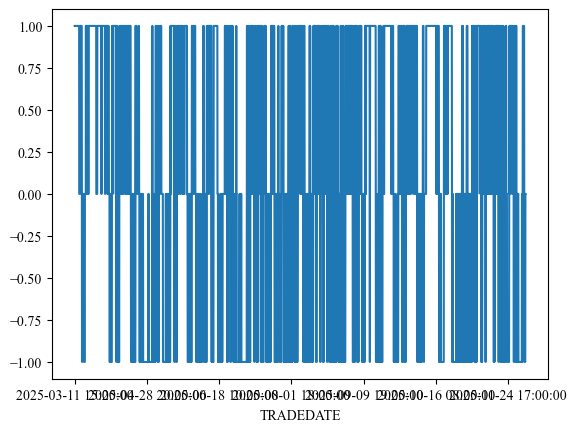

In [25]:
position_wf.plot()

In [26]:
metrics_wf

{'total_return': np.float64(0.31380360714567024),
 'annual_return': np.float64(0.27573296752610177),
 'annual_vol': np.float64(0.04557654614915731),
 'sharpe': np.float64(6.049887295621675),
 'max_drawdown': -0.01371994751290373,
 'n_trades': 452,
 'n_long': 239,
 'n_short': 213}

In [27]:
equity_wf

TRADEDATE
2025-03-11 15:00:00    1.000000e+06
2025-03-11 16:00:00    1.000000e+06
2025-03-11 17:00:00    1.000000e+06
2025-03-11 18:00:00    9.998566e+05
2025-03-11 19:00:00    9.996908e+05
                           ...     
2025-12-02 16:00:00    1.313981e+06
2025-12-02 17:00:00    1.313846e+06
2025-12-02 18:00:00    1.313617e+06
2025-12-02 19:00:00    1.313804e+06
2025-12-02 20:00:00    1.313804e+06
Length: 3120, dtype: float64

In [28]:
df_equity = equity_wf.to_frame(name='equity')
df_equity.index = pd.to_datetime(df_equity.index)
df_equity

,equity
TRADEDATE,
2025-03-11 15:00:00,1.000000e+06
2025-03-11 16:00:00,1.000000e+06
2025-03-11 17:00:00,1.000000e+06
2025-03-11 18:00:00,9.998566e+05
2025-03-11 19:00:00,9.996908e+05
...,...
2025-12-02 16:00:00,1.313981e+06
2025-12-02 17:00:00,1.313846e+06
2025-12-02 18:00:00,1.313617e+06


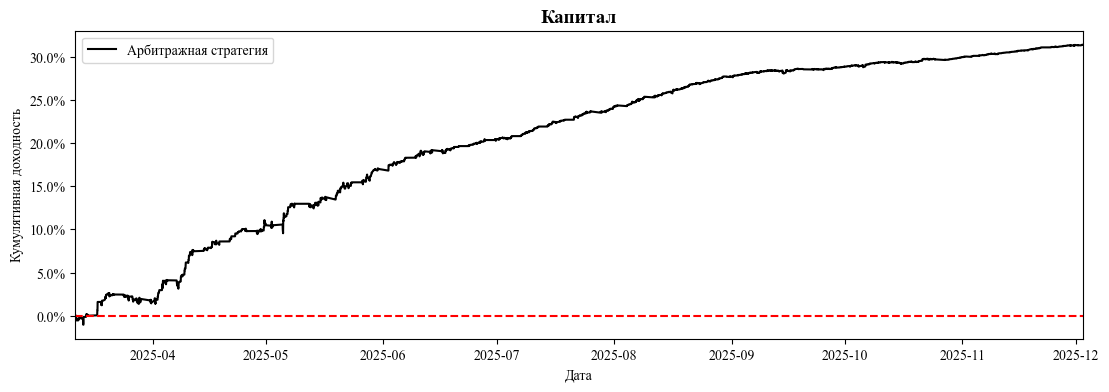

In [29]:
#Капитализация: экспонента от накопленных лог-доходностей
df_equity_ret = df_equity['equity'] / df_equity['equity'].iloc[0] - 1

fig, ax = plt.subplots(figsize=(13, 4))
plt.plot(df_equity_ret, label="Арбитражная стратегия", color = 'black')
plt.title("Капитал", fontdict={'fontweight':'bold','fontsize':14})
#plt.grid()
plt.legend()

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0,decimals=1))
ax.axhline(0, color='red', linestyle='--')

ax.set_xlabel('Дата')
ax.set_ylabel('Кумулятивная доходность')
ax.margins(x=0)
#plt.savefig(r"Рисунки/walk‑forward капитал.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
betas_wf.index = pd.to_datetime(betas_wf.index)
betas_wf

,alpha,beta_RI,beta_Si
TRADEDATE,,,
2025-03-11 15:00:00,6.759637,0.480540,0.039882
2025-03-11 16:00:00,6.759637,0.480540,0.039882
2025-03-11 17:00:00,6.759637,0.480540,0.039882
2025-03-11 18:00:00,6.759637,0.480540,0.039882
2025-03-11 19:00:00,6.759637,0.480540,0.039882
...,...,...,...
2025-12-02 16:00:00,-9.812275,0.987188,0.964691
2025-12-02 17:00:00,-9.812275,0.987188,0.964691
2025-12-02 18:00:00,-9.812275,0.987188,0.964691


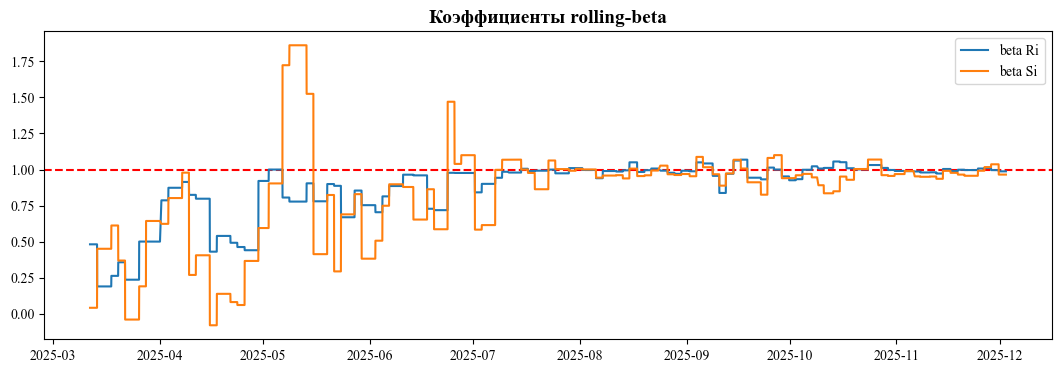

In [31]:
coef = betas_wf.drop(columns='alpha')
fig, ax = plt.subplots(figsize=(13, 4))

ax.axhline(1, color='red', linestyle='--')

ax.set_title('Коэффициенты rolling-beta', fontdict={'fontweight':'bold','fontsize':14})
ax.plot(coef.index, coef['beta_RI'], label='beta Ri')
ax.plot(coef.index, coef['beta_Si'], label='beta Si')
ax.legend()
plt.show()

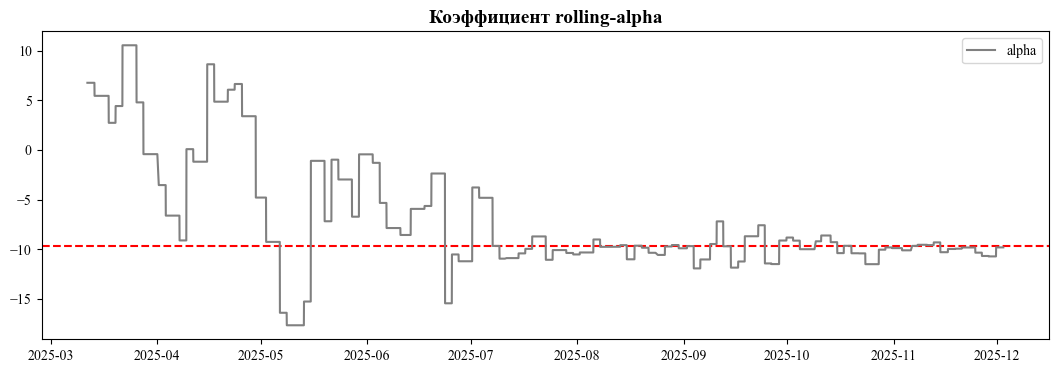

In [32]:
coef = betas_wf.drop(columns=['beta_RI', 'beta_Si'])
fig, ax = plt.subplots(figsize=(13, 4))

ax.axhline(-9.65, color='red', linestyle='--')

ax.set_title('Коэффициент rolling-alpha', fontdict={'fontweight':'bold','fontsize':14})
ax.plot(coef.index, coef['alpha'], label='alpha', color = 'grey')
ax.legend()
plt.show()

### Анализ beta

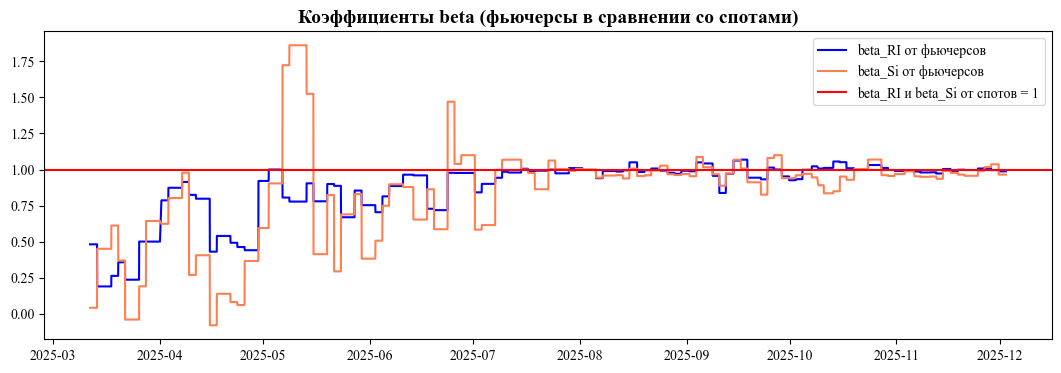

In [33]:
coef = betas_wf[['beta_RI', 'beta_Si']].dropna()

fig, ax = plt.subplots(figsize=(13, 4))
ax.set_title('Коэффициенты beta (фьючерсы в сравнении со спотами)',  fontdict={'fontweight':'bold','fontsize':14})

# rolling-беты по фьючам
ax.plot(coef.index, coef['beta_RI'], label='beta_RI от фьючерсов', color='blue')
ax.plot(coef.index, coef['beta_Si'], label='beta_Si от фьючерсов', color = 'coral')
ax.axhline(1, color='red', label=f'beta_RI и beta_Si от спотов = {1}')

# горизонтальные линии по спотовым β
#ax.axhline(beta_RI_spot, color='red',label=f'beta_RI_spot = {beta_RI_spot:.2f}')
#ax.axhline(beta_Si_spot, color='green',label=f'beta_Si_spot = {beta_Si_spot:.2f}')

ax.legend()
plt.show()

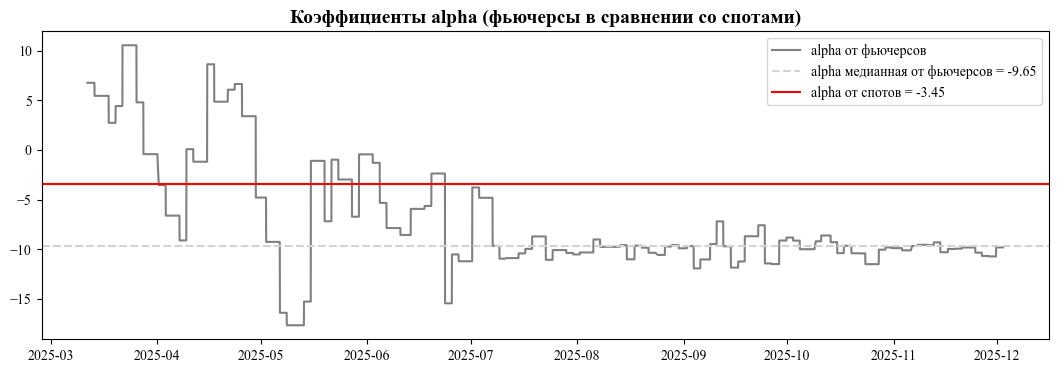

In [34]:
coef = betas_wf[['alpha']].dropna()

fig, ax = plt.subplots(figsize=(13, 4))
ax.set_title('Коэффициенты alpha (фьючерсы в сравнении со спотами)',  fontdict={'fontweight':'bold','fontsize':14})

# rolling-беты по фьючам
ax.plot(coef.index, coef['alpha'], label='alpha от фьючерсов', color='grey')
ax.axhline(-9.65, color='lightgrey', linestyle='--',label=f'alpha медианная от фьючерсов = {-9.65}')

# горизонтальные линии по спотовым β
ax.axhline(alpha_spot, color='red',label=f'alpha от спотов = {alpha_spot:.2f}')
#ax.axhline(beta_Si_spot, color='green',label=f'beta_Si_spot = {beta_Si_spot:.2f}')

ax.legend()
plt.show()

In [35]:
wald_pvalues.index = pd.to_datetime(wald_pvalues.index)
wald_pvalues

,wald_joint,wald_alpha,wald_beta_RI,wald_beta_Si
TRADEDATE,,,,
2025-03-11 15:00:00,0.0,0.0,0.000000,0.000000
2025-03-11 16:00:00,0.0,0.0,0.000000,0.000000
2025-03-11 17:00:00,0.0,0.0,0.000000,0.000000
2025-03-11 18:00:00,0.0,0.0,0.000000,0.000000
2025-03-11 19:00:00,0.0,0.0,0.000000,0.000000
...,...,...,...,...
2025-12-02 16:00:00,0.0,0.0,0.125616,0.000152
2025-12-02 17:00:00,0.0,0.0,0.125616,0.000152
2025-12-02 18:00:00,0.0,0.0,0.125616,0.000152


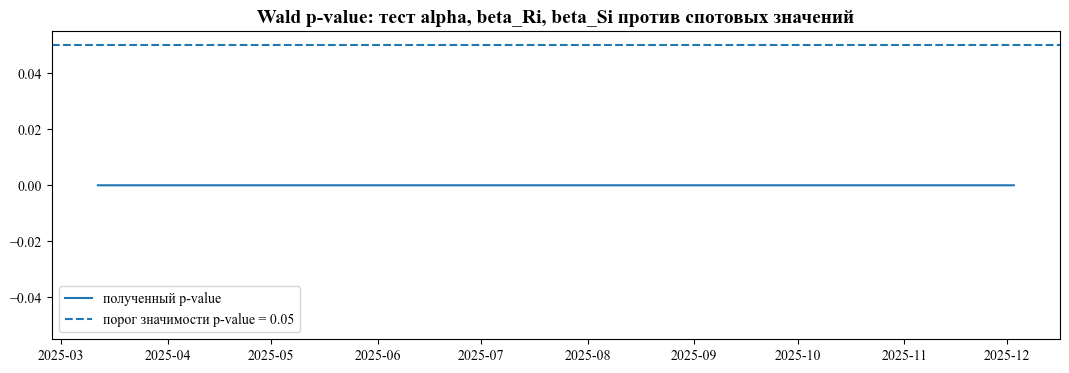

In [36]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(wald_pvalues.index, wald_pvalues['wald_joint'], label='полученный p-value')
ax.axhline(0.05, linestyle='--', label='порог значимости p-value = 0.05')
ax.set_title('Wald p-value: тест alpha, beta_Ri, beta_Si против спотовых значений', fontdict={'fontweight':'bold','fontsize':14})
ax.legend()
plt.show()

`p-value > 0.05`: нет статистических оснований отвергать H0: beta фьючерсов не отличаются от beta по споту (на выбранном уровне значимости). \
`p-value < 0.05`: отличия существенные, веса по фьючам нельзя считать равными спотовым.

**Итог:** На каждом окне `beta` и `alpha` фьючерсной регрессии существенно отличаются от спотовых коэффициентов `alpha_spot`, `beta_RI_spot`, `beta_Si_spot`. Локальные фьючерсные параметры не совпадают с эталоном по споту. Спот-параметры описывают "идеальную" связь, тогда как связь во фьючерсах может быть иной. \

Поэтому это аргумент в пользу того, что фиксировать веса на уровне спотовых `beta` и не обновлять их явно нельзя. Динамический пересчёт `beta` оправдан.